# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.chromatin_model import ChromatinModel


config1, config2 = load_config_from_replication_runs(
    'output/prototype_pipeline_subset/single_replication/', chrom=4)


Shifting mu0, gamma1, and gamma2, for alpha...


In [567]:
from src.combined_chromatin_model import CombinedChromatinModel
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

[autoreload of src.deconvolution_solver failed: Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 273, in check
    superreload(m, reload, self.old_objects)
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 471, in superreload
    module = reload(module)
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 604, in _exec
  File "<frozen importlib._bootstrap_external>", line 839, in exec_module
  File "<frozen importlib._bootstrap_external>", line 976, in get_code
  File "<frozen importlib._bootstrap_external>", line 906, in source_to_code
  File "<frozen importlib._bootstrap>", line 219, in _call_with_frames_removed
  File "/Users/trung/Resea

In [568]:
chrom = 5
mnase_span = (408000, 409001)
combined_model.load_mnase_span(chrom, mnase_span)

Loading chromosome reads: 5
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Loading chromosome reads: 5
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


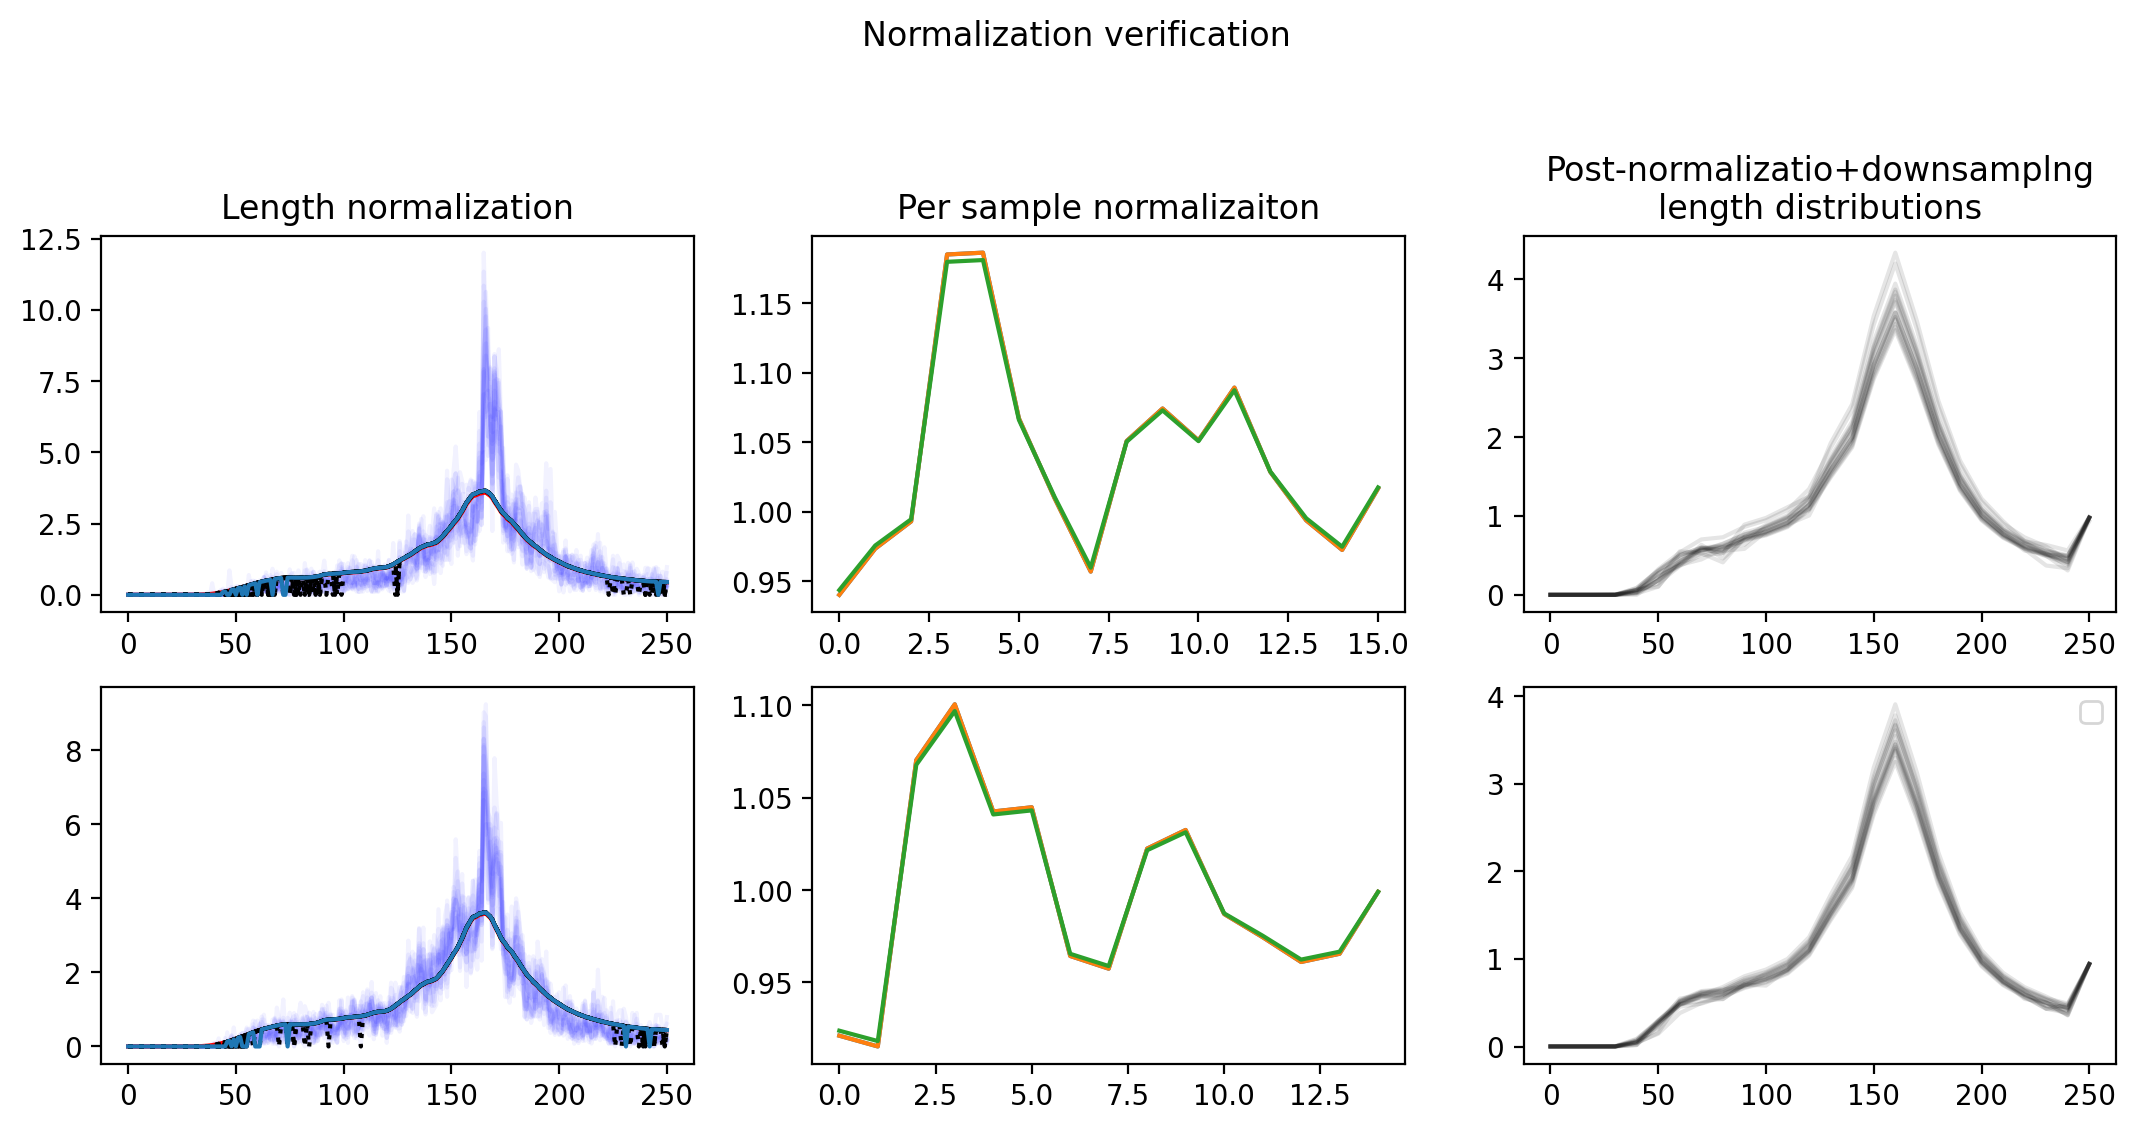

In [569]:
fig = combined_model.plot_normalization_sanity_check()

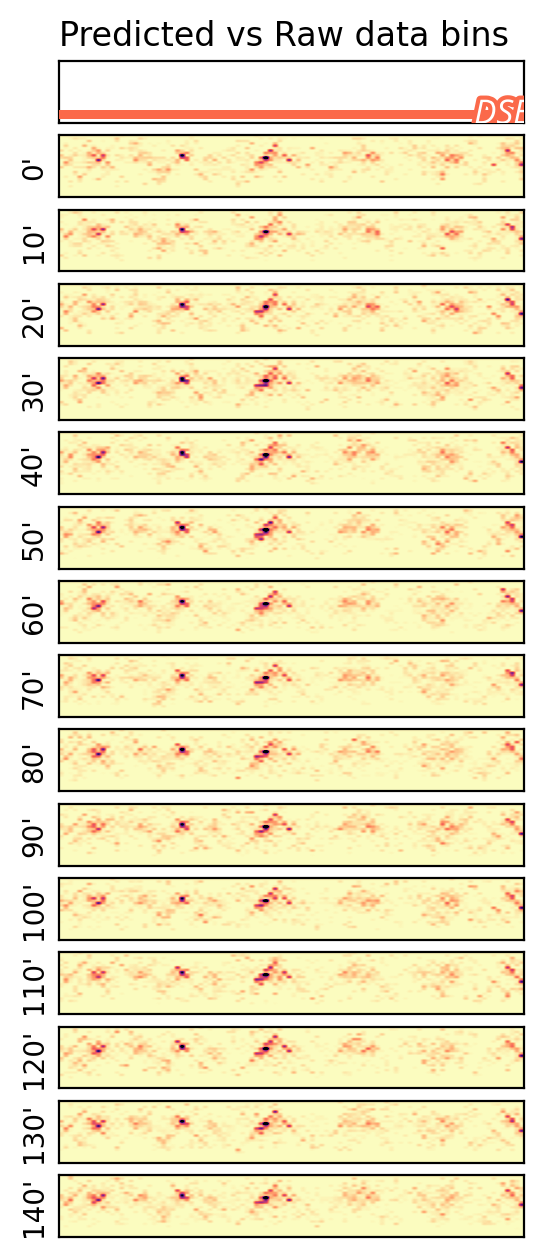

In [597]:
fig = combined_model.chrom2_model.plot_raw_data(figsize=(3, 7))

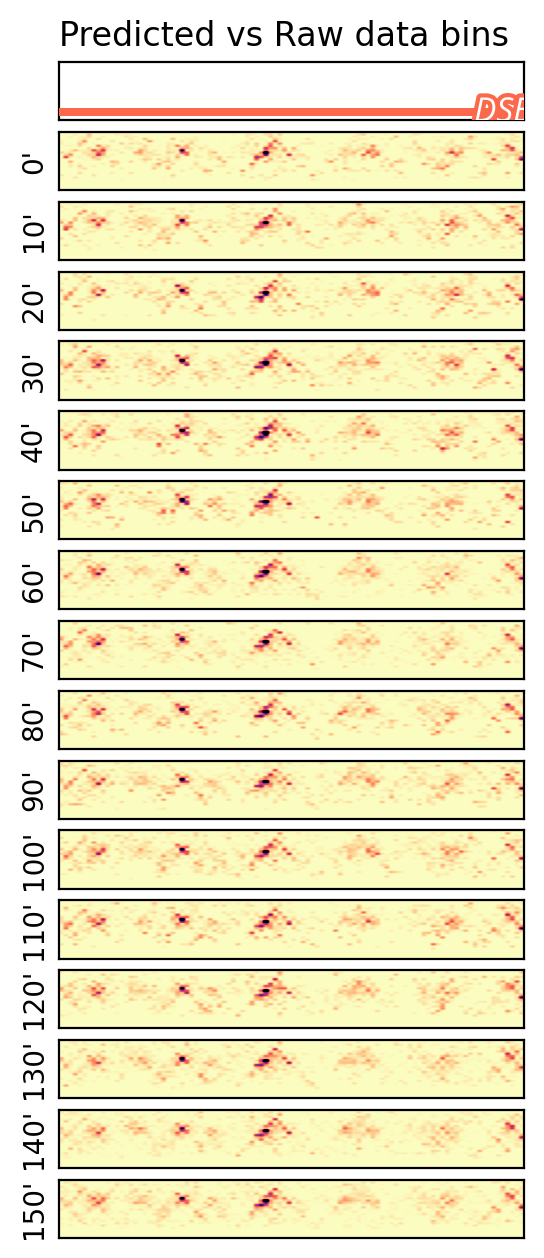

In [598]:
fig = combined_model.chrom1_model.plot_raw_data(figsize=(3, 7))

In [575]:
combined_model.setup_deconv_model()

todo: Loading copy correction N, Fr, B, testing with prototype replication data
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


In [576]:
combined_model.deconvolve(gamma=0.01, kappa=0, verbose=True)

0/2600 - 00:00:00.000
500/2600 - 00:00:09.782
1000/2600 - 00:01:29.922
1500/2600 - 00:02:52.797
2000/2600 - 00:04:16.801
2500/2600 - 00:05:37.123
Completed - 00:05:53.712


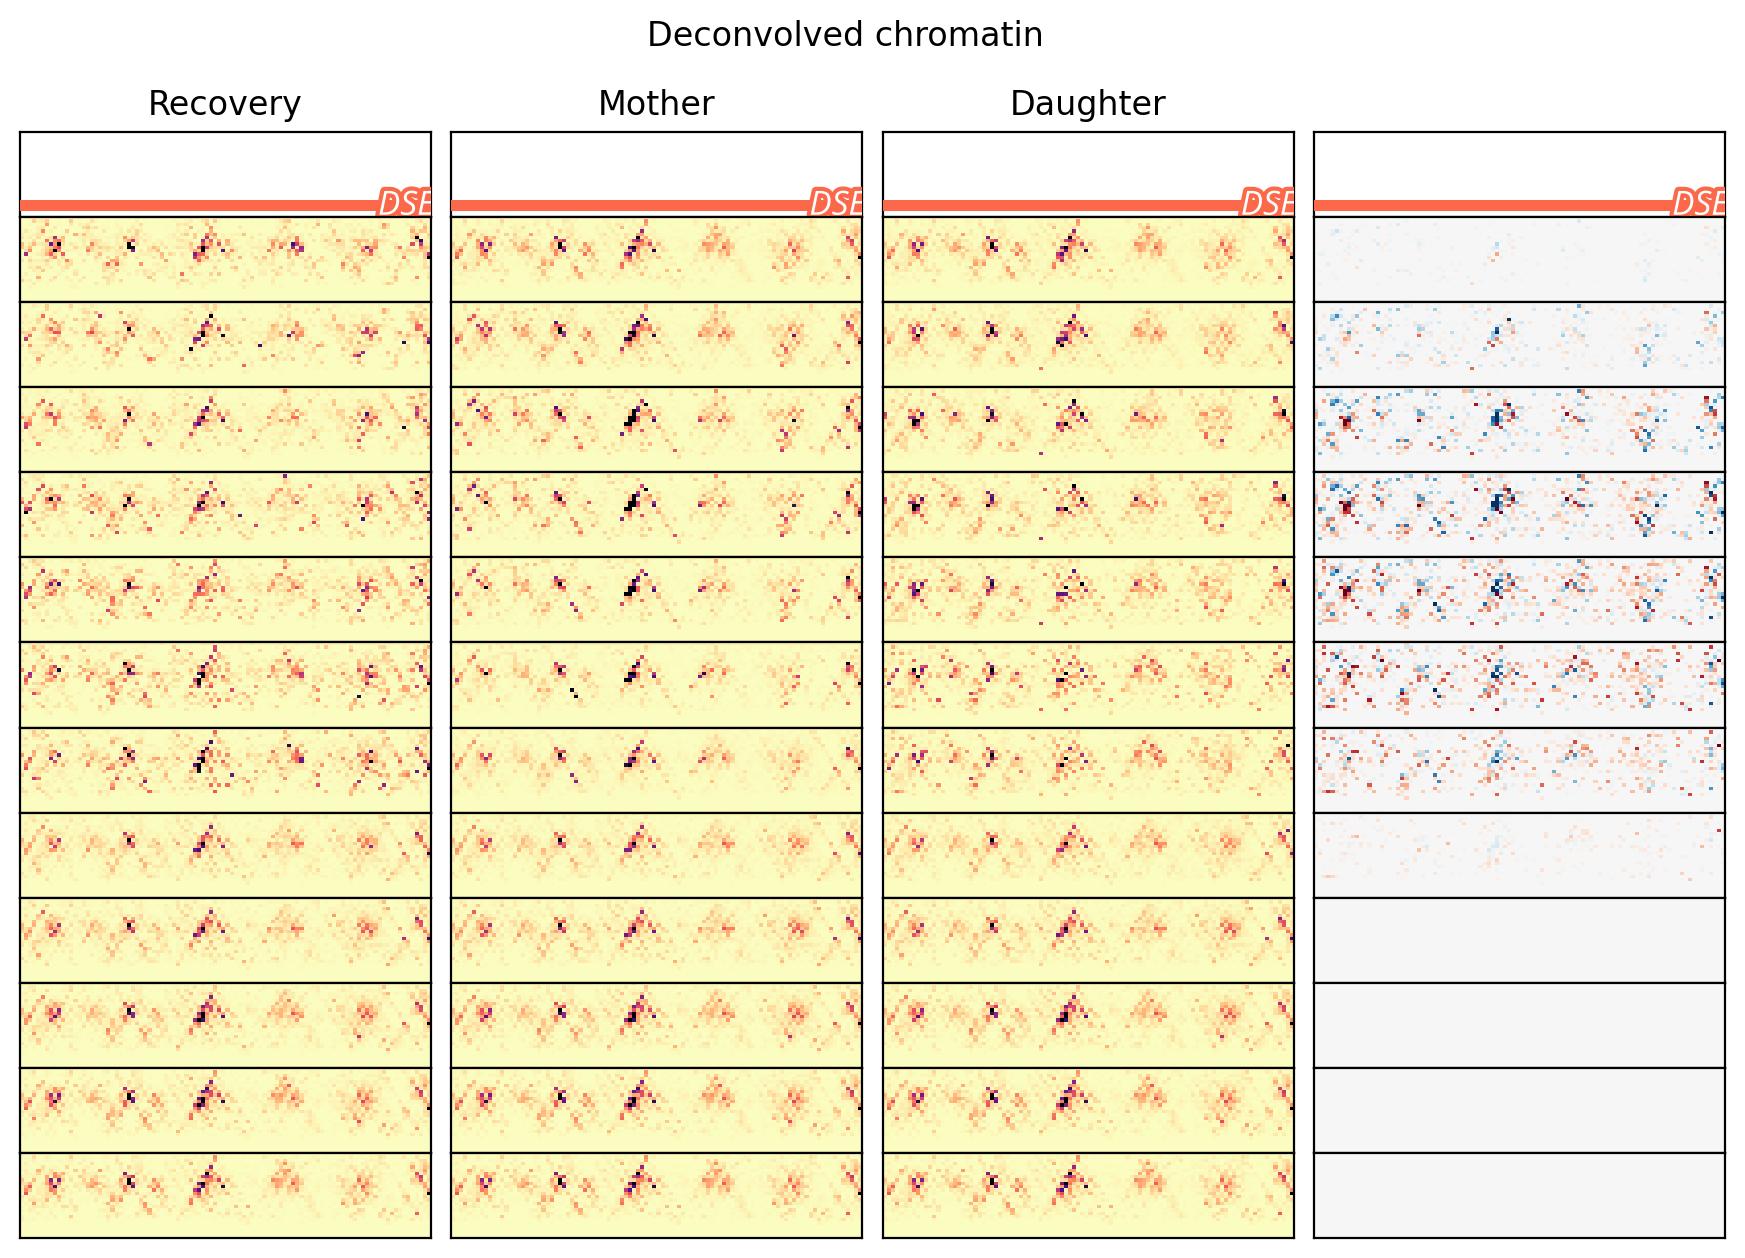

In [599]:
combined_model.plot_branches(figsize=(11, 7))

In [602]:
gene = orfs[orfs['gene'] == 'DSE1']
mid = (gene.TSS // 2000) * 2000
mid-5000, mid+5000

(orf_name
 YER124C    403000
 Name: TSS, dtype: int64,
 orf_name
 YER124C    413000
 Name: TSS, dtype: int64)

In [606]:
window_set_2kb = create_windows_to_deconvolve(round_window=2000)

Defining test windows to deconvolve, rounded to the nearest 2000
408000
408000 (408000, 418000)
Criteria for gene selection: Verified genes greater than 500 long,less than 0.5 mean expression, less than 0.1 std expression
Number of verified genes with low expression: 41


In [564]:
from src.geneset import create_windows_to_deconvolve

window_set_10kb = create_windows_to_deconvolve(round_window=10000)
window_set_2kb = create_windows_to_deconvolve(round_window=2000)

window_set_10kb.to_csv("datasets/computed_mnase/test_window_set_10kb.csv", index=False)
window_set_2kb.to_csv("datasets/computed_mnase/test_window_set_2kb.csv", index=False)

window_set_2kb

Defining test windows to deconvolve, rounded to the nearest 10000
Criteria for gene selection: Verified genes greater than 500 long,less than 0.5 mean expression, less than 0.1 std expression
Number of verified genes with low expression: 41
Defining test windows to deconvolve, rounded to the nearest 2000
Criteria for gene selection: Verified genes greater than 500 long,less than 0.5 mean expression, less than 0.1 std expression
Number of verified genes with low expression: 41


,start,group,chr,end,name
0,1018000,early_chr4,4,1028000,early_chr4
1,1348000,early_chr4,4,1358000,early_chr4
2,1150000,early_chr4,4,1160000,early_chr4
3,334000,early_chr4,4,344000,early_chr4
4,462000,early_chr4,4,472000,early_chr4
5,674000,late_chr4,4,684000,late_chr4
6,780000,late_chr4,4,790000,late_chr4
7,668000,late_chr4,4,678000,late_chr4
8,958000,late_chr4,4,968000,late_chr4
9,964000,late_chr4,4,974000,late_chr4


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [408]:
output_directory = \
    'output/prototype_pipeline_subset/'
chromatin_deconvolution_directory = \
    f'{output_directory}/chromatin_deconvolution/'

def load_deconvolved_window(chrom, span, chromatin_deconvolution_directory):
    filepath = f'deconvolution_data/chr{chrom}/chr{chrom}_{span[0]}_{span[1]}_F.npy'
    deconv_F_path = f'{chromatin_deconvolution_directory}/{filepath}'
    F_data = np.load(deconv_F_path)
    return F_data


(149, 26000)

In [422]:
def load_combined_model_for_row(row):
    """"Load the deconvolution data from disk and place in combined model for
    analysis"""
    mnase_span = row.start, row.end
    chrom = row.chr

    loaded_F_data = load_deconvolved_window(chrom, mnase_span, 
        chromatin_deconvolution_directory)

    config1, config2 = load_config_from_replication_runs(
        f'{output_directory}/single_replication/', chrom=4)

    from src.combined_chromatin_model import CombinedChromatinModel
    combined_model = CombinedChromatinModel(config1=config1, config2=config2)
    combined_model.load_mnase_span(chrom, mnase_span)
    combined_model.setup_deconv_model()
    combined_model.solver.F = loaded_F_data
    
    return combined_model


In [450]:
# Streamline of combined model loading of deconvolution data from disk
# from the trial windows
window_set_10kb = pd.read_csv('datasets/computed_mnase/test_window_set_10kb.csv')
row = window_set_10kb[window_set_10kb['name'] == 'CLB3'] .iloc[0]
combined_model = load_combined_model_for_row(row)

Shifting mu0, gamma1, and gamma2, for alpha...
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 9999) to (16, 26, 1000)
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 9999) to (15, 26, 1000)
todo: Loading copy correction N, Fr, B, testing with prototype replication data
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


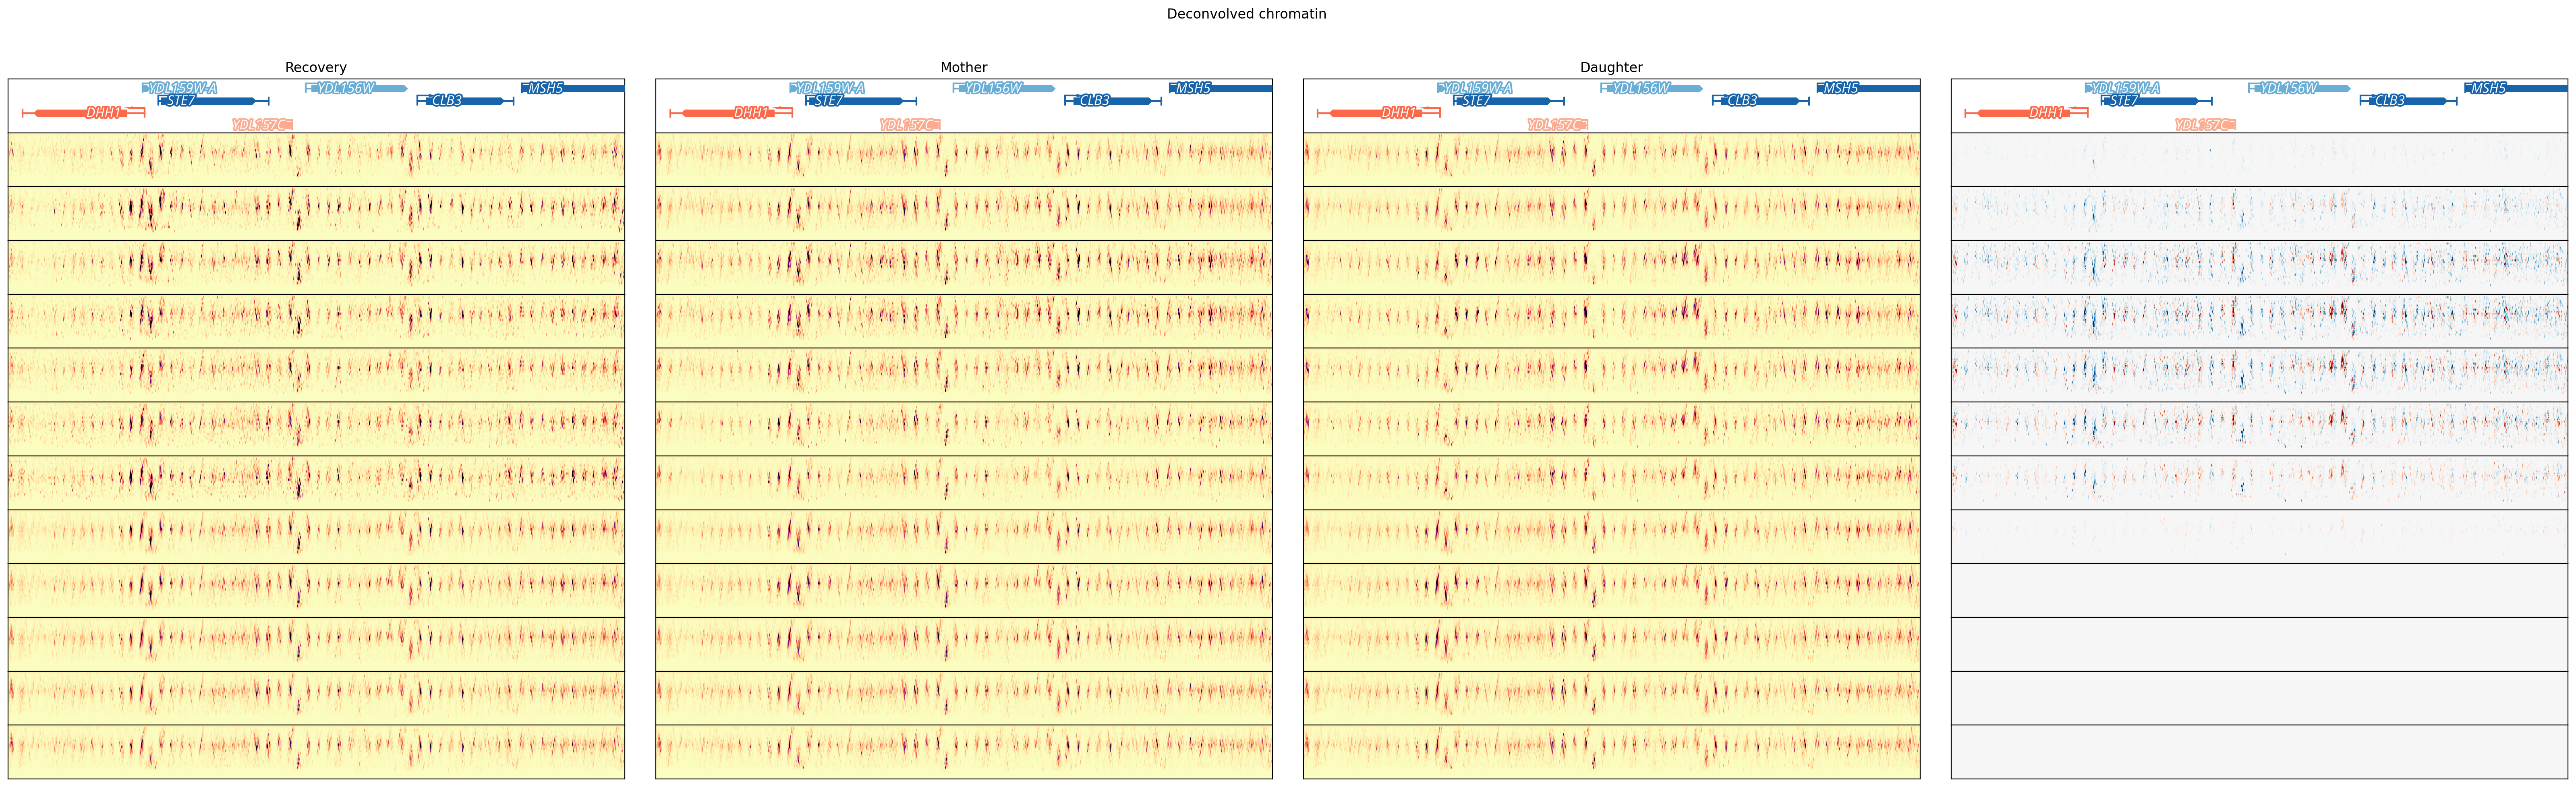

In [451]:
combined_model.plot_branches(figsize=(41, 11))

In [565]:
loaded_F_data.shape

(149, 26000)

In [566]:
window_set_2kb

,start,group,chr,end,name
0,1018000,early_chr4,4,1028000,early_chr4
1,1348000,early_chr4,4,1358000,early_chr4
2,1150000,early_chr4,4,1160000,early_chr4
3,334000,early_chr4,4,344000,early_chr4
4,462000,early_chr4,4,472000,early_chr4
5,674000,late_chr4,4,684000,late_chr4
6,780000,late_chr4,4,790000,late_chr4
7,668000,late_chr4,4,678000,late_chr4
8,958000,late_chr4,4,968000,late_chr4
9,964000,late_chr4,4,974000,late_chr4
